## **Visualization**
Using the merged dataset from the preprocessing notebook, we build the final Performance Ratio Evolution chart step by step — starting with a plain scatter and layering in complexity one piece at a time.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

### **Loading the merged data**

In [3]:
data = pd.read_csv("data/preprocessed_data.csv")

In [5]:
data.head()

,Date,PR,GHI
0,2019-07-01,69.575676,3.256608
1,2019-07-02,79.314411,3.976767
2,2019-07-03,61.020006,2.811867
3,2019-07-04,83.262576,3.658408
4,2019-07-05,82.124440,5.590683


In [6]:
data.shape

(982, 3)

### **S1: a plain scatter plot**
Just PR against Date, no styling — a baseline before adding the GHI colour coding.

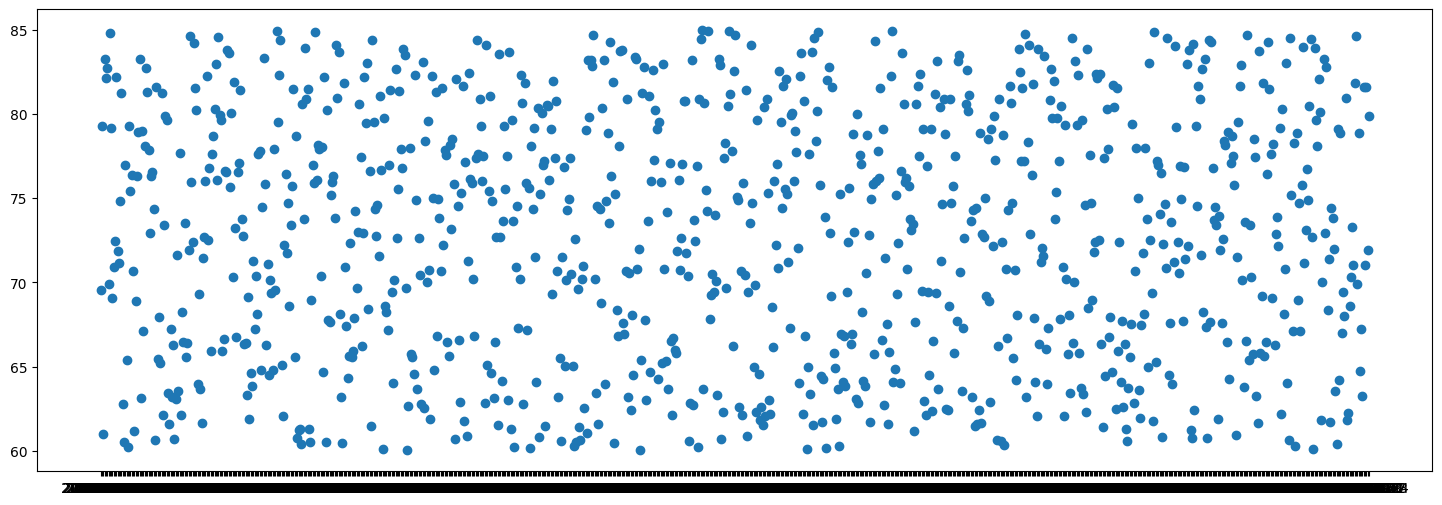

In [7]:
plt.figure(figsize=(18,6))

plt.scatter(
    data["Date"],
    data["PR"]
)

plt.show()

### **S2: Colour-coding by GHI**
Each day's GHI is bucketed into 4 bands, and each band gets its own colour, so the chart shows at a glance how much sunlight was available on a given day.

In [8]:
def get_color(ghi):
    if ghi < 2:
        return "navy"
    elif ghi < 4:
        return "skyblue"
    elif ghi < 6:
        return "orange"
    else:
        return "brown"

In [9]:
data["Color"] = data["GHI"].apply(get_color)

In [10]:
data.head()

,Date,PR,GHI,Color
0,2019-07-01,69.575676,3.256608,skyblue
1,2019-07-02,79.314411,3.976767,skyblue
2,2019-07-03,61.020006,2.811867,skyblue
3,2019-07-04,83.262576,3.658408,skyblue
4,2019-07-05,82.124440,5.590683,orange


### **Re-plotting with colour applied**

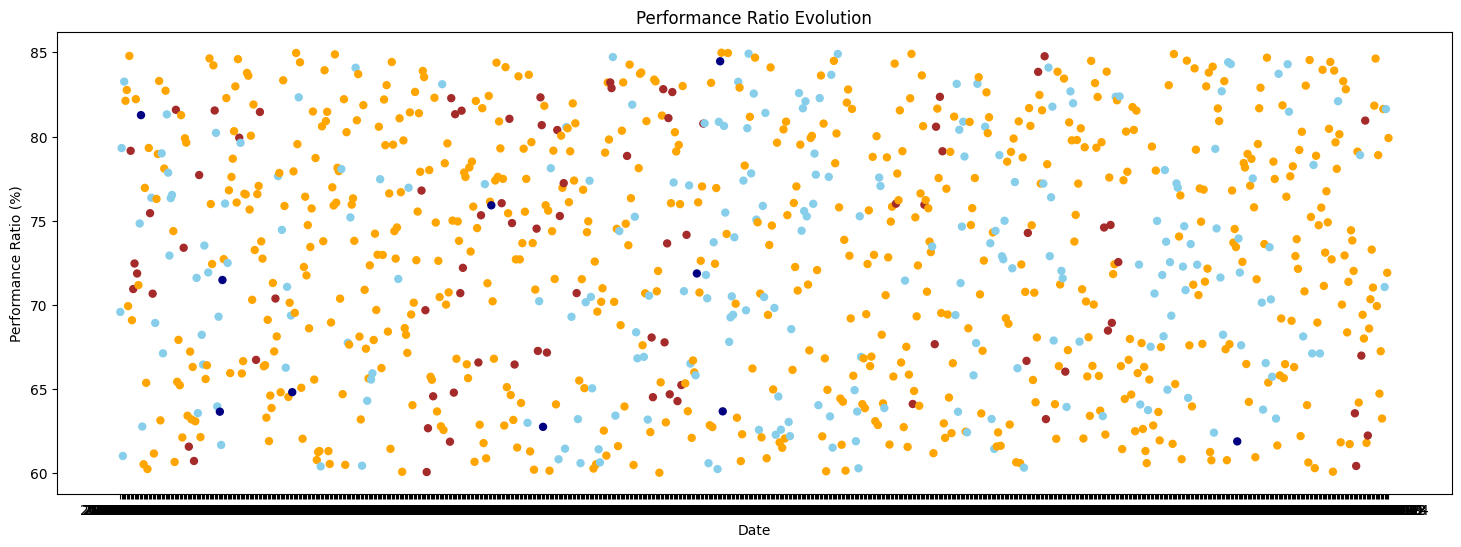

In [11]:
plt.figure(figsize=(18,6))

plt.scatter(
    data["Date"],
    data["PR"],
    c=data["Color"],
    s=25
)

plt.xlabel("Date")
plt.ylabel("Performance Ratio (%)")
plt.title("Performance Ratio Evolution")

plt.show()

### **S3: Rolling Mean 30-Day's**
Day-to-day PR is noisy, so a 30-day rolling average line makes it easier to see whether performance is trending up or down over time.

In [12]:
data["PR_30MA"] = (
    data["PR"]
    .rolling(window=30)
    .mean()
)

In [15]:
data.head(300)

,Date,PR,GHI,Color,PR_30MA
0,2019-07-01,69.575676,3.256608,skyblue,NaN
1,2019-07-02,79.314411,3.976767,skyblue,NaN
2,2019-07-03,61.020006,2.811867,skyblue,NaN
3,2019-07-04,83.262576,3.658408,skyblue,NaN
4,2019-07-05,82.124440,5.590683,orange,NaN
...,...,...,...,...,...
295,2020-04-21,76.039520,6.457483,brown,73.841475
296,2020-04-22,77.483346,4.577167,orange,73.828859
297,2020-04-23,62.827069,5.740242,orange,73.336480
298,2020-04-24,84.121803,5.062733,orange,73.925012


### **Adding the moving average line to the chart**

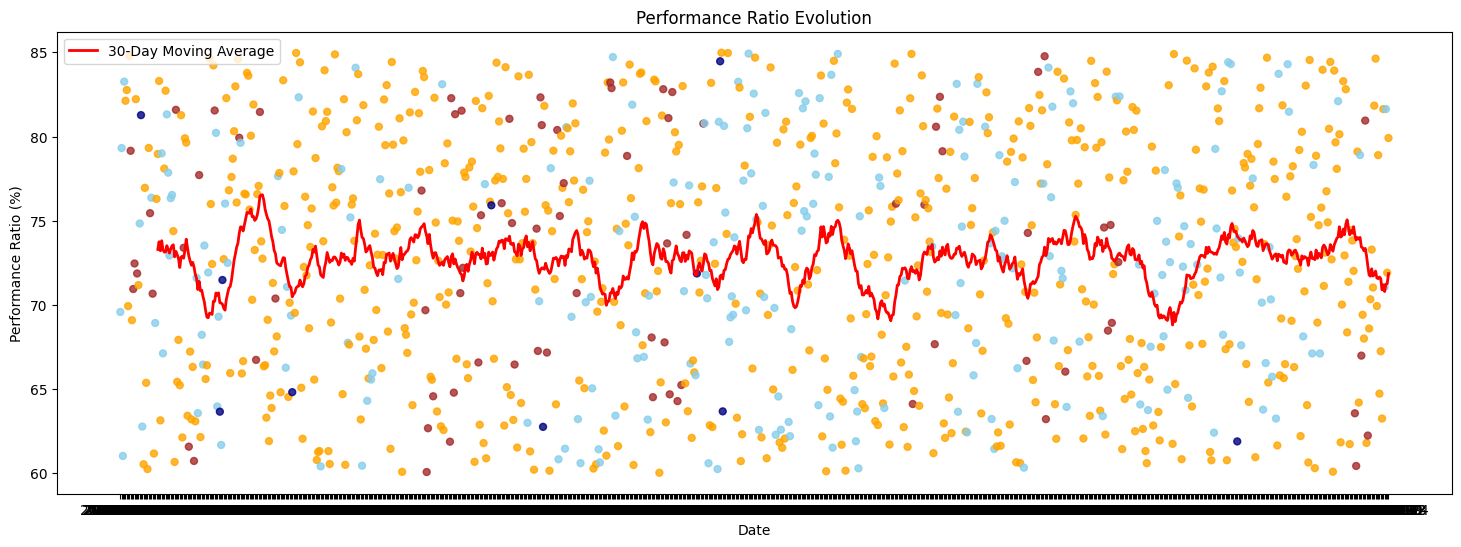

In [16]:
plt.figure(figsize=(18,6))

# Scatter
plt.scatter(
    data["Date"],
    data["PR"],
    c=data["Color"],
    s=25,
    alpha=0.8
)

# 30-Day Moving Average
plt.plot(
    data["Date"],
    data["PR_30MA"],
    color="red",
    linewidth=2,
    label="30-Day Moving Average"
)

plt.xlabel("Date")
plt.ylabel("Performance Ratio (%)")
plt.title("Performance Ratio Evolution")

plt.legend()

plt.show()

### **S4:Defining the budget target**
The plant's target PR degrades by 0.8% every financial year (Jul–Jun), so before we can plot a budget line we first need to know which financial year each date falls into.

In [17]:
def budget_year(date):
    """
    Returns the budget year index.

    Jul 2019 - Jun 2020 -> 0
    Jul 2020 - Jun 2021 -> 1
    Jul 2021 - Jun 2022 -> 2
    """
    if date.month >= 7:
        return date.year - 2019
    else:
        return date.year - 2020

In [51]:
print(budget_year(pd.Timestamp("2019-07-01")))   # 0
print(budget_year(pd.Timestamp("2020-03-01")))   # 0
print(budget_year(pd.Timestamp("2020-07-01")))   # 1
print(budget_year(pd.Timestamp("2021-10-01")))   # 2

0
0
1
2


### **Computing the budget PR itself, from that financial year index**

In [52]:
Base_Budget = 73.9
Degradation = 0.008      # 0.8%

In [53]:
def calculate_budget(date):
    years = budget_year(date)
    return Base_Budget * ((1 - Degradation) ** years)

### **Double-checking the Date column**
Before applying `calculate_budget` row by row, confirm `Date` is a real datetime and not still a string.

In [23]:
data.dtypes

Date        object
PR         float64
GHI        float64
Color       object
PR_30MA    float64
dtype: object

In [24]:
data["Date"] = pd.to_datetime(data["Date"])

In [ ]:
data.dtypes

Date       datetime64[ns]
PR                float64
GHI               float64
Color              object
PR_30MA           float64
dtype: object

### **Applying the budget formula to every row**

In [26]:
data["Budget"] = data["Date"].apply(calculate_budget)

In [30]:
data.head()

,Date,PR,GHI,Color,PR_30MA,Budget
0,2019-07-01,69.575676,3.256608,skyblue,NaN,73.9
1,2019-07-02,79.314411,3.976767,skyblue,NaN,73.9
2,2019-07-03,61.020006,2.811867,skyblue,NaN,73.9
3,2019-07-04,83.262576,3.658408,skyblue,NaN,73.9
4,2019-07-05,82.124440,5.590683,orange,NaN,73.9


### **Flagging which days beat their budget**

In [31]:
data["Above_Budget"] = data["PR"] > data["Budget"]

In [32]:
data.head()

,Date,PR,GHI,Color,PR_30MA,Budget,Above_Budget
0,2019-07-01,69.575676,3.256608,skyblue,NaN,73.9,False
1,2019-07-02,79.314411,3.976767,skyblue,NaN,73.9,True
2,2019-07-03,61.020006,2.811867,skyblue,NaN,73.9,False
3,2019-07-04,83.262576,3.658408,skyblue,NaN,73.9,True
4,2019-07-05,82.124440,5.590683,orange,NaN,73.9,True


In [33]:
print(data["Above_Budget"].sum())

479


### **Tagging each row with its financial year**

In [34]:
data["Budget_Year"] = data["Date"].apply(budget_year)

In [35]:
data.head()

,Date,PR,GHI,Color,PR_30MA,Budget,Above_Budget,Budget_Year
0,2019-07-01,69.575676,3.256608,skyblue,NaN,73.9,False,0
1,2019-07-02,79.314411,3.976767,skyblue,NaN,73.9,True,0
2,2019-07-03,61.020006,2.811867,skyblue,NaN,73.9,False,0
3,2019-07-04,83.262576,3.658408,skyblue,NaN,73.9,True,0
4,2019-07-05,82.124440,5.590683,orange,NaN,73.9,True,0


### **Counting how many days beat budget, per financial year**

In [ ]:
above_budget = (
    data.groupby("Budget_Year")["Above_Budget"]
    .sum()
)

print(above_budget)

Budget_Year
0    179
1    170
2    130
Name: Above_Budget, dtype: int64


### **Rolling averages for the stats box**
A small helper to compute average PR over the last N days — used for the 7 / 30 / 60 / 90 / 365-day stats shown on the final chart.

In [37]:
def average_last_days(df, days):
    return df.tail(days)["PR"].mean()

In [38]:
avg7 = average_last_days(data, 7)
avg30 = average_last_days(data, 30)
avg60 = average_last_days(data, 60)
avg90 = average_last_days(data, 90)
avg365 = average_last_days(data, 365)

lifetime = data["PR"].mean()

In [39]:
print(avg7)
print(avg30)
print(avg60)
print(avg90)
print(avg365)
print(lifetime)

73.80366172428572
71.85599481666668
73.00926396499997
73.05061490655555
72.83230558076711
72.71493266345215


### **Checking in with everything layered so far**
One more look at the chart before wrapping all of this into a single reusable function.

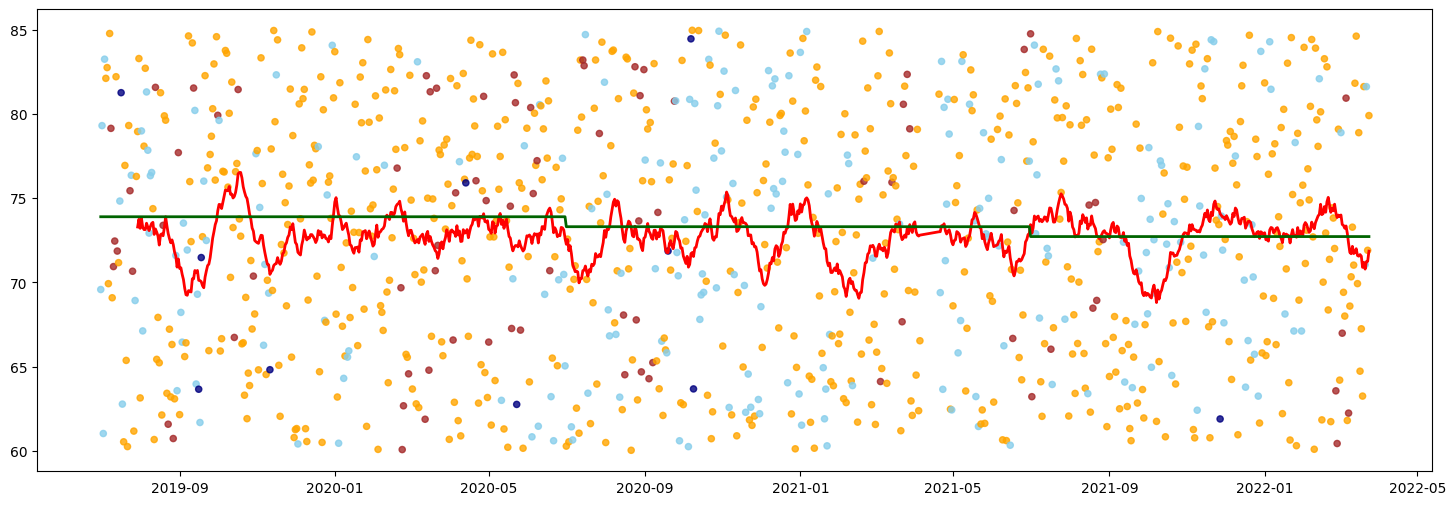

In [54]:
plt.figure(figsize=(18,6))

plt.scatter(
    data["Date"],
    data["PR"],
    c=data["Color"],
    s=20,
    alpha=0.8
)

plt.plot(
    data["Date"],
    data["PR_30MA"],
    color="red",
    linewidth=2
)

plt.plot(
    data["Date"],
    data["Budget"],
    color="darkgreen",
    linewidth=2
)

### **Wrapping it all into one function**
Everything above — the colours, moving average, budget line, per-year annotations, and stats box — gets bundled into `plot_performance_ratio()` so it can be reused on any date-filtered subset of the data. This is what powers the `--start_date` / `--end_date` bonus feature later in `main.py`.

In [59]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D


def plot_performance_ratio(data):

    # Statistics
  
    def average_last_days(df, days):
        return df.tail(days)["PR"].mean()

    avg7 = average_last_days(data, 7)
    avg30 = average_last_days(data, 30)
    avg60 = average_last_days(data, 60)
    avg90 = average_last_days(data, 90)
    avg365 = average_last_days(data, 365)
    avg_lifetime = data["PR"].mean()

    # Points Above Budget
  
    points_above = (data["PR"] > data["Budget"]).sum()
    percentage = (points_above / len(data)) * 100

    
    # Figure
    
    fig, ax = plt.subplots(figsize=(18,8))

    
    # Scatter Plot
    
    ax.scatter(
        data["Date"],
        data["PR"],
        c=data["Color"],
        s=10,
        alpha=0.8
    )

    
    # 30-Day Moving Average
    
    ax.plot(
        data["Date"],
        data["PR_30MA"],
        color="red",
        linewidth=2,
        label="30-Day Moving Average"
    )

    
    # Budget Line
    
    ax.plot(
        data["Date"],
        data["Budget"],
        color="darkgreen",
        linewidth=2,
        label="Budget PR"
    )

    
    # Title
    
    ax.set_title(
        f"Performance Ratio Evolution\nFrom {data['Date'].min().date()} to {data['Date'].max().date()}",
        fontsize=16,
        fontweight="bold"
    )

    
    # Axis Labels
    
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Performance Ratio (%)", fontsize=12)

   
    # X Axis Formatting
    
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=3)
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%b/%y")
    )

    plt.xticks(rotation=45)

    
    # Grid
    
    ax.grid(True, linestyle="--", alpha=0.3)

    
    # Custom Legend
    
    legend_elements = [

        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='GHI < 2',
            markerfacecolor='navy',
            markersize=8
        ),

        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='2 ≤ GHI < 4',
            markerfacecolor='skyblue',
            markersize=8
        ),

        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='4 ≤ GHI < 6',
            markerfacecolor='orange',
            markersize=8
        ),

        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label='GHI ≥ 6',
            markerfacecolor='brown',
            markersize=8
        ),

        Line2D(
            [0], [0],
            color='red',
            lw=2,
            label='30-Day Moving Average'
        ),

        Line2D(
            [0], [0],
            color='darkgreen',
            lw=2,
            label='Budget PR'
        ),
    ]

    ax.legend(handles=legend_elements, loc="upper left")

    
    # Points Above Budget
    
    ax.text(
        0.35,
        0.28,
        f"Points above Target Budget PR : {points_above}/{len(data)} = {percentage:.1f}%",
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold"
    )

    
    # Statistics Box
    
    stats_text = (
        f"Average PR Last 7 Days : {avg7:.1f}%\n"
        f"Average PR Last 30 Days : {avg30:.1f}%\n"
        f"Average PR Last 60 Days : {avg60:.1f}%\n"
        f"Average PR Last 90 Days : {avg90:.1f}%\n"
        f"Average PR Last 365 Days : {avg365:.1f}%\n"
        f"Average PR Lifetime : {avg_lifetime:.1f}%"
    )

    ax.text(
        0.98,
        0.05,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        ha="right",
        va="bottom",
        bbox=dict(
            facecolor="white",
            alpha=0.8,
            edgecolor="gray"
        )
    )

    ax.set_xlim(
    data["Date"].min(),
    data["Date"].max()
    )

    
    # Save
    
    plt.tight_layout()

    plt.savefig(
        "performance_ratio.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### **Running it on the full dataset to produce the finished chart**

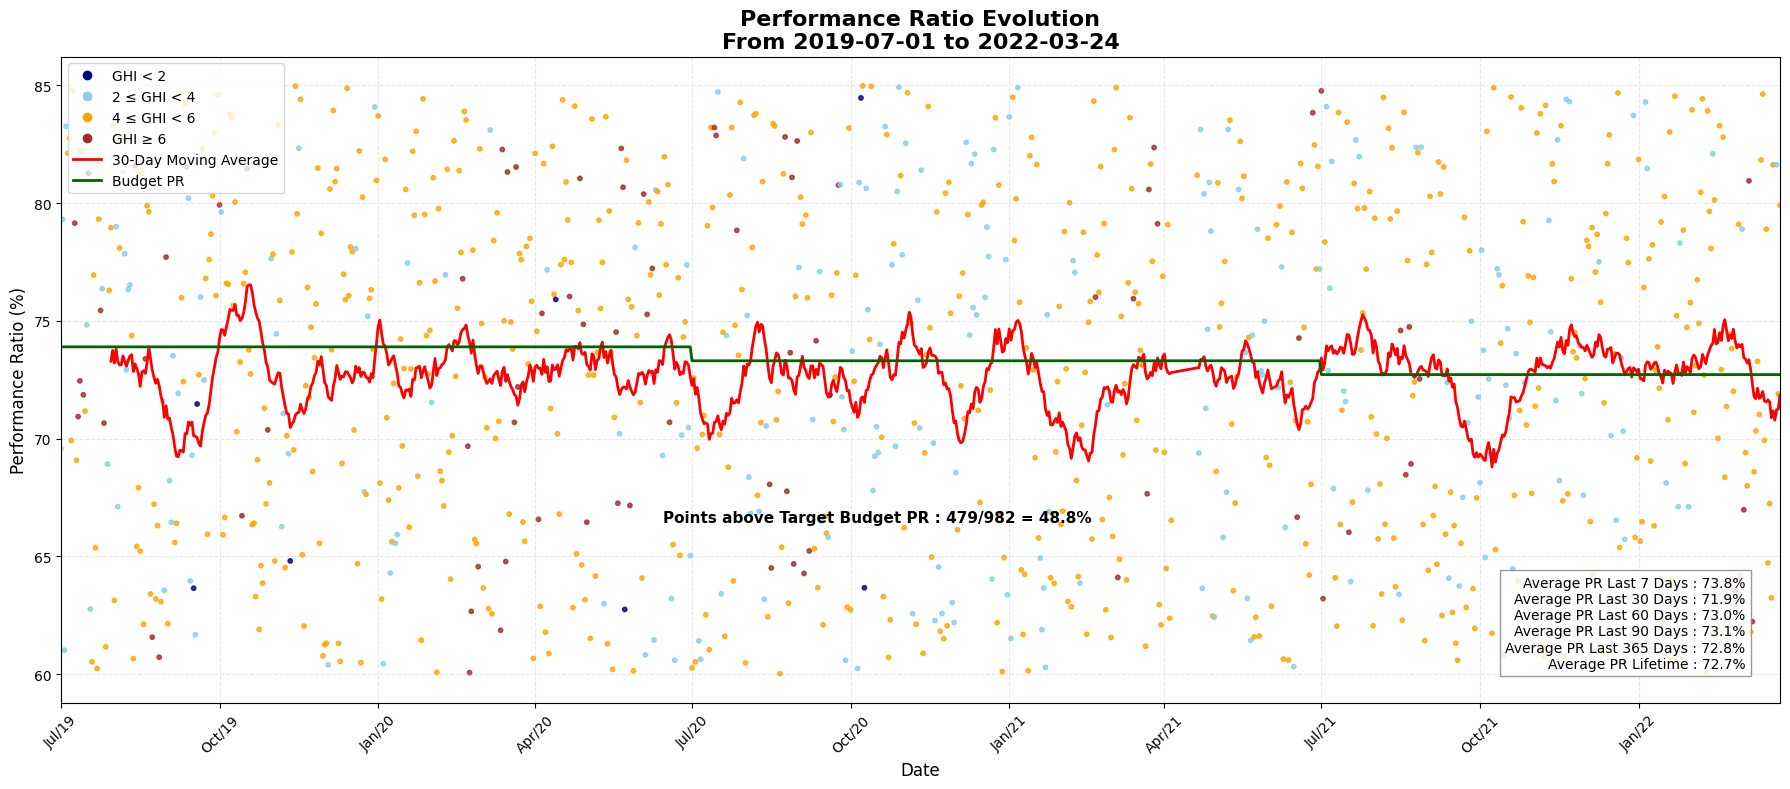

In [60]:
plot_performance_ratio(data)